# 01 - Exploration des données

Ce notebook a pour objectif de comprendre les jeux de données disponibles dans `data/raw/` et de vérifier les principaux signaux utiles pour un système de recommandation contextuel.

Nous explorons ici :
- MovieLens 100K
- MovieLens 1M
- RetailRocket

L'exploration est organisée autour des questions suivantes :
1. Combien d'utilisateurs, d'items et d'interactions ?
2. Quelles sont les distributions de notes et de types d'événements ?
3. Quels signaux temporels apparaissent dans les données ?


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print('Python:', sys.version.split()[0])
print('pandas :', pd.__version__)
print('numpy :', np.__version__)
print('matplotlib :', plt.matplotlib.__version__)
print('seaborn :', sns.__version__)


Python: 3.12.13
pandas : 3.0.3
numpy : 2.4.6
matplotlib : 3.10.9
seaborn : 0.13.2


## Chargement des données brutes

Les données se trouvent dans `../data/raw/` depuis le notebook. Nous utilisons les fichiers MovieLens 100K, MovieLens 1M et RetailRocket en données brutes.


In [2]:
NOTEBOOK_ROOT = Path('.')
DATA_ROOT = (NOTEBOOK_ROOT / '..' / 'data' / 'raw').resolve()
print('DATA_ROOT =', DATA_ROOT)
print('MovieLens 100K files:')
print(sorted((DATA_ROOT / 'movielens' / 'ml-100k').iterdir()))
print('MovieLens 1M files:')
print(sorted((DATA_ROOT / 'movielens' / 'ml-1m').iterdir()))
print('RetailRocket files:')
print(sorted((DATA_ROOT / 'retailrocket').iterdir()))


DATA_ROOT = /home/mrtds/Documents/my_projects/context-aware-recsys/data/raw
MovieLens 100K files:
[PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-100k/links.csv'), PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-100k/movies.csv'), PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-100k/ratings.csv'), PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-100k/tags.csv'), PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-100k/u.data')]
MovieLens 1M files:
[PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-1m/README'), PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-1m/ml-1m.test.auc.csv'), PosixPath('/home/mrtds/Documents/my_projects/context-aware-recsys/data/raw/movielens/ml-1m/ml-1m.test.csv'), PosixPath('/home/mrtds/Docum

In [3]:
ml100k_path = DATA_ROOT / 'movielens' / 'ml-100k'
ml1m_path = DATA_ROOT / 'movielens' / 'ml-1m'
rr_path = DATA_ROOT / 'retailrocket'

ml100k = pd.read_csv(ml100k_path / 'u.data', sep='	', names=['user_id', 'item_id', 'rating', 'timestamp'])
movies_100k = pd.read_csv(ml100k_path / 'movies.csv')
ml1m = pd.read_csv(ml1m_path / 'ratings.dat', sep='::', names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python', encoding='latin-1')
movies_1m = pd.read_csv(ml1m_path / 'movies.dat', sep='::', names=['item_id', 'title', 'genres'], engine='python', encoding='latin-1')
rr = pd.read_csv(rr_path / 'events.csv')

ml100k['timestamp'] = pd.to_datetime(ml100k['timestamp'], unit='s')
ml1m['timestamp'] = pd.to_datetime(ml1m['timestamp'], unit='s')
rr['timestamp'] = pd.to_datetime(rr['timestamp'], unit='ms')

print('ml100k:', ml100k.shape)
print('movies_100k:', movies_100k.shape)
print('ml1m:', ml1m.shape)
print('movies_1m:', movies_1m.shape)
print('retailrocket:', rr.shape)


ml100k: (100000, 4)
movies_100k: (9125, 3)
ml1m: (1000209, 4)
movies_1m: (3883, 3)
retailrocket: (2756101, 5)


## MovieLens 100K — Vue d'ensemble

Le jeu de données MovieLens 100K est un bon point de départ pour analyser le comportement utilisateur/item et les signaux temporels.


In [4]:
def summarize_movielens(df, label):
    print(f'--- {label} ---')
    print('Interactions :', len(df))
    print('Utilisateurs uniques :', df['user_id'].nunique())
    print('Items uniques :', df['item_id'].nunique())
    print('Rating min/max :', df['rating'].min(), df['rating'].max())
    print('Timestamp range :', df['timestamp'].min(), '→', df['timestamp'].max())
    print(df[['rating']].describe())
    print()

summarize_movielens(ml100k, 'MovieLens 100K')
summarize_movielens(ml1m, 'MovieLens 1M')


--- MovieLens 100K ---
Interactions : 100000
Utilisateurs uniques : 943
Items uniques : 1682
Rating min/max : 1 5
Timestamp range : 1997-09-20 03:05:10 → 1998-04-22 23:10:38
              rating
count  100000.000000
mean        3.529860
std         1.125674
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000

--- MovieLens 1M ---
Interactions : 1000209
Utilisateurs uniques : 6040
Items uniques : 3706
Rating min/max : 1 5
Timestamp range : 2000-04-25 23:05:32 → 2003-02-28 17:49:50
             rating
count  1.000209e+06
mean   3.581564e+00
std    1.117102e+00
min    1.000000e+00
25%    3.000000e+00
50%    4.000000e+00
75%    4.000000e+00
max    5.000000e+00



### Distribution des notes

On examine la distribution des notes dans MovieLens 100K et MovieLens 1M pour vérifier la polarité et les valeurs extrêmes.


/tmp/ipykernel_1052654/2547547038.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ml100k, palette='Blues', ax=axes[0])
/tmp/ipykernel_1052654/2547547038.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ml1m, palette='Greens', ax=axes[1])


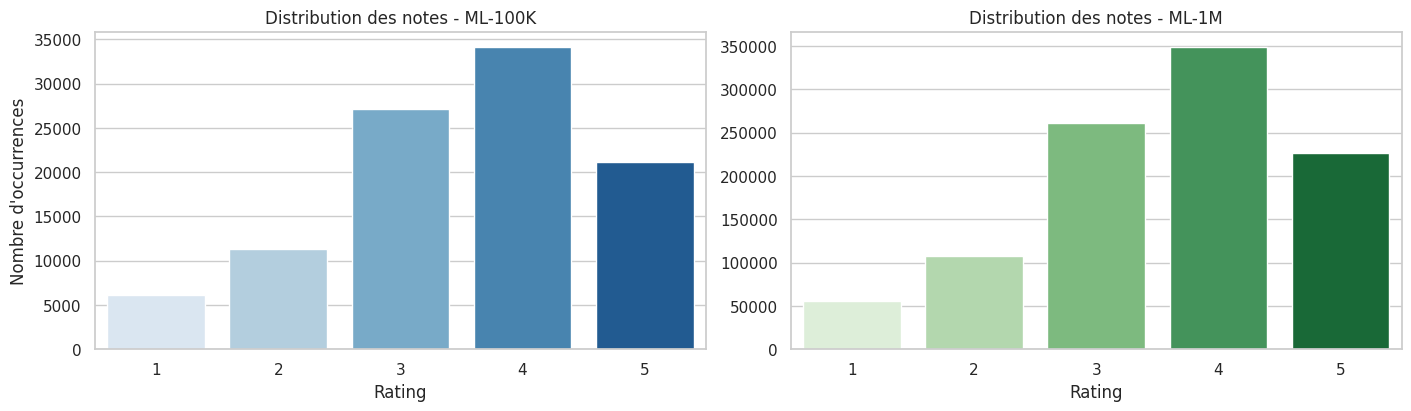

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.countplot(x='rating', data=ml100k, palette='Blues', ax=axes[0])
axes[0].set_title('Distribution des notes - ML-100K')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Nombre d\'occurrences')

sns.countplot(x='rating', data=ml1m, palette='Greens', ax=axes[1])
axes[1].set_title('Distribution des notes - ML-1M')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('')
plt.show()


### Analyse temporelle de MovieLens 100K

Le timestamp est converti en date/heure pour détecter des patterns journaliers et hebdomadaires.


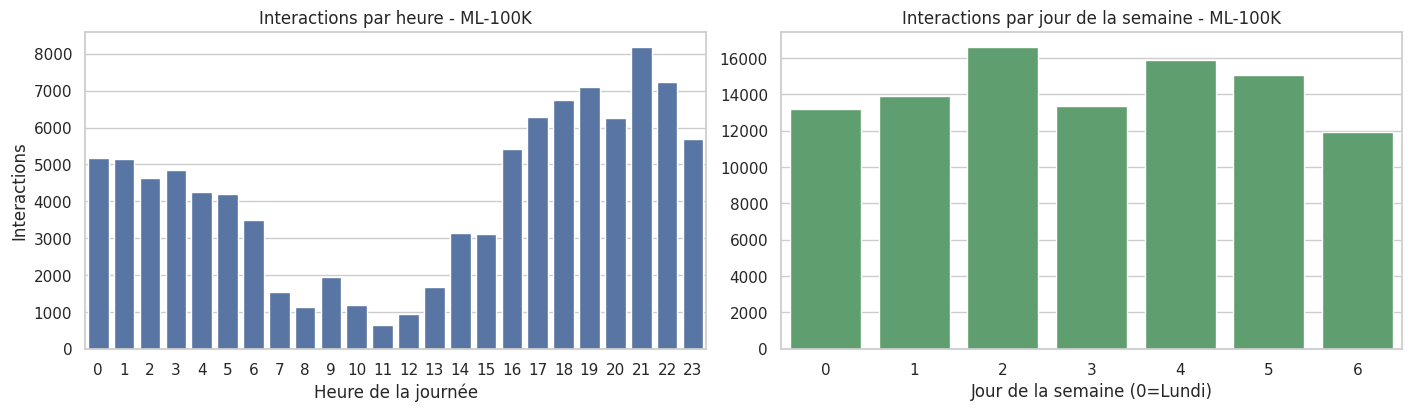

In [7]:
ml100k['hour'] = ml100k['timestamp'].dt.hour
ml100k['day_of_week'] = ml100k['timestamp'].dt.dayofweek
ml100k['date'] = ml100k['timestamp'].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.countplot(x='hour', data=ml100k, color='#4C72B0', ax=axes[0])
axes[0].set_title('Interactions par heure - ML-100K')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Interactions')

sns.countplot(x='day_of_week', data=ml100k, color='#55A868', ax=axes[1])
axes[1].set_title('Interactions par jour de la semaine - ML-100K')
axes[1].set_xlabel('Jour de la semaine (0=Lundi)')
axes[1].set_ylabel('')
plt.show()


### Exploration des films et des genres

Nous regardons comment les genres sont distribués et quels sont les films les plus représentés.


,genre,count
0,Drama,4365
1,Comedy,3315
2,Thriller,1729
3,Romance,1545
4,Action,1545
5,Adventure,1117
6,Crime,1100
7,Horror,877
8,Sci-Fi,792
9,Fantasy,654


/tmp/ipykernel_1052654/935177860.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts.head(12), x='count', y='genre', palette='coolwarm')


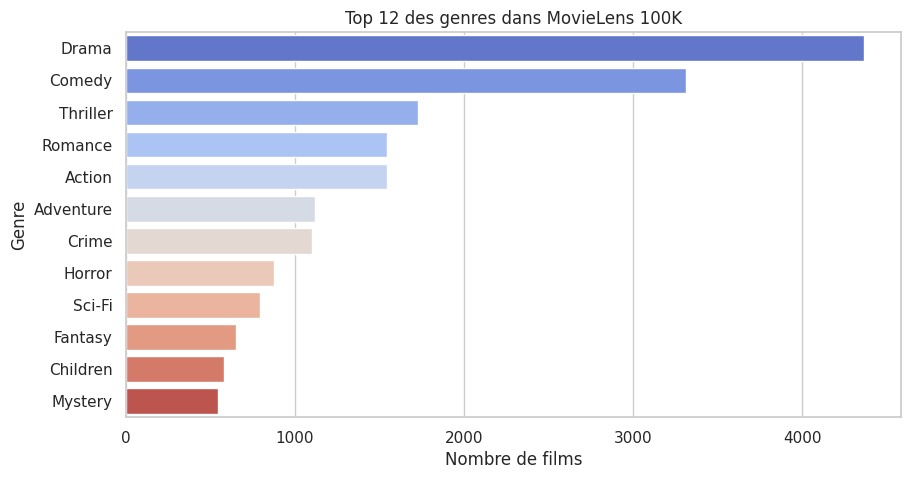

In [8]:
movies_100k['genres'] = movies_100k['genres'].fillna('Unknown')
genre_series = movies_100k['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

display(genre_counts.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_counts.head(12), x='count', y='genre', palette='coolwarm')
plt.title('Top 12 des genres dans MovieLens 100K')
plt.xlabel('Nombre de films')
plt.ylabel('Genre')
plt.show()


## MovieLens 1M — Premier aperçu

Nous vérifions rapidement la taille et les principales statistiques de MovieLens 1M pour comparer avec ML-100K.


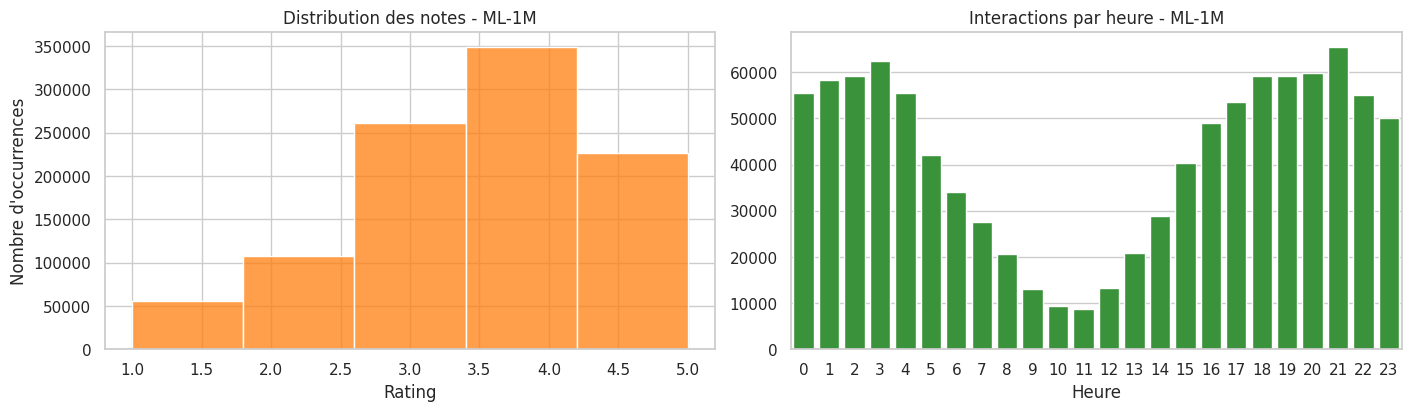

In [10]:
ml1m['hour'] = ml1m['timestamp'].dt.hour
ml1m['day_of_week'] = ml1m['timestamp'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.histplot(ml1m['rating'], bins=5, kde=False, color='#FF7F0E', ax=axes[0])
axes[0].set_title('Distribution des notes - ML-1M')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Nombre d\'occurrences')

sns.countplot(x='hour', data=ml1m, color='#2CA02C', ax=axes[1])
axes[1].set_title('Interactions par heure - ML-1M')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('')
plt.show()


## RetailRocket — Données e-commerce

RetailRocket apporte un format événementiel différent : `view`, `addtocart`, `transaction`. C'est un matériau intéressant pour tester des features de type intention et de type d'événement.


In [12]:
rr_summary = rr[['visitorid', 'itemid', 'event']].copy()
rr_summary.columns = ['user_id', 'item_id', 'event']
print('RetailRocket - shape :', rr_summary.shape)
print('Utilisateurs uniques :', rr_summary['user_id'].nunique())
print('Items uniques :', rr_summary['item_id'].nunique())
print('Types d\'événements :')
print(rr_summary['event'].value_counts())


RetailRocket - shape : (2756101, 3)
Utilisateurs uniques : 1407580
Items uniques : 235061
Types d'événements :
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


/tmp/ipykernel_1052654/877599451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='event', data=rr, order=rr['event'].value_counts().index, palette='viridis', ax=axes[0])


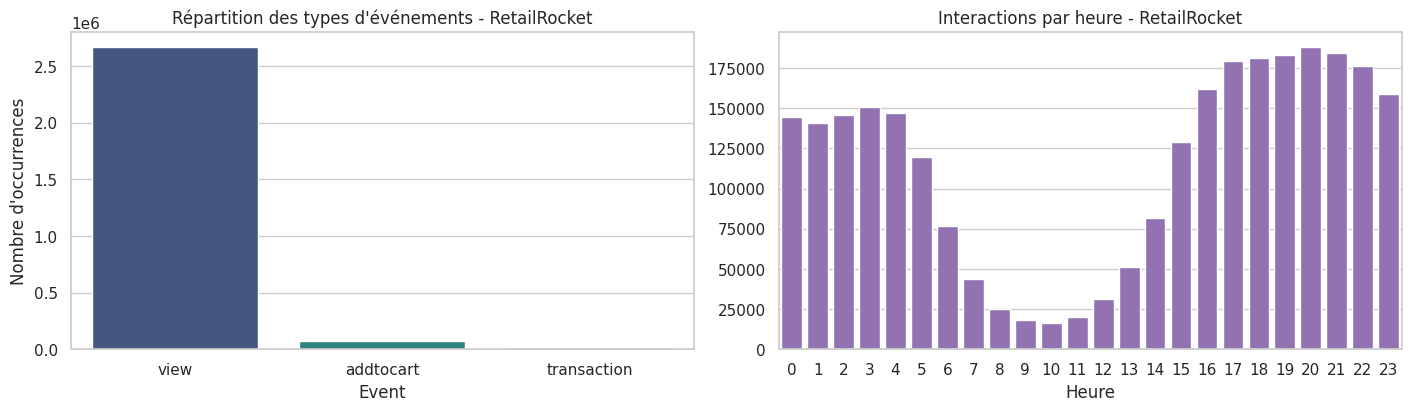

In [15]:
rr['hour'] = rr['timestamp'].dt.hour
rr['day_of_week'] = rr['timestamp'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.countplot(x='event', data=rr, order=rr['event'].value_counts().index, palette='viridis', ax=axes[0])
axes[0].set_title('Répartition des types d\'événements - RetailRocket')
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Nombre d\'occurrences')

sns.countplot(x='hour', data=rr, color='#9467BD', ax=axes[1])
axes[1].set_title('Interactions par heure - RetailRocket')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('')
plt.show()


## Conclusions provisoires

- MovieLens 100K et 1M fournissent des timestamps utiles pour extraire des features temporelles.
- La distribution des notes est majoritairement positive, ce qui est typique des datasets de recommandation.
- RetailRocket présente un fort déséquilibre vers les vues, ce qui est important pour traiter le feedback implicite.

Ce notebook prépare le terrain pour le feature engineering et l'entraînement des modèles contextuels dans les notebooks suivants.
